In [52]:
!pip install librosa
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow
!pip install keras

In [53]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler

In [54]:
dataset_path = r"C:\Users\91892\Desktop\Project\Speech Emotion Recognition Using Spectrogram-Based CNN Models\RAVDESS Emotional speech audio"

paths = []
labels = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            paths.append(os.path.join(root, file))

            emotion = file.split("-")[2]
            labels.append(emotion)

df = pd.DataFrame()
df["path"] = paths
df["emotion"] = labels

df.head()

,path,emotion
0,C:\Users\91892\Desktop\Project\Speech Emotion ...,01
1,C:\Users\91892\Desktop\Project\Speech Emotion ...,01
2,C:\Users\91892\Desktop\Project\Speech Emotion ...,01
3,C:\Users\91892\Desktop\Project\Speech Emotion ...,01
4,C:\Users\91892\Desktop\Project\Speech Emotion ...,02


In [55]:
print("Total audio files:", len(df))

Total audio files: 2880


In [56]:
emotion_map = {
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fearful",
    "07":"disgust",
    "08":"surprised"
}

df["emotion"] = df["emotion"].map(emotion_map)

In [57]:
def extract_spectrogram(file_path):

    signal, sr = librosa.load(file_path, duration=3, offset=0.5)

    spectrogram = librosa.feature.melspectrogram(
        y=signal,
        sr=sr
    )

    spectrogram = librosa.power_to_db(spectrogram)

    return spectrogram

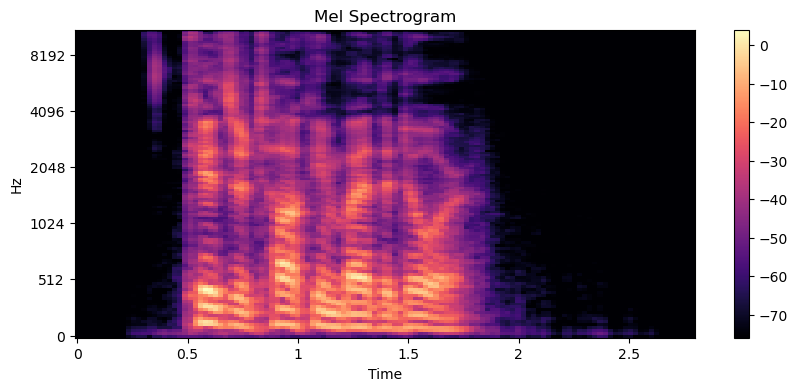

In [58]:
sample = extract_spectrogram(df.path[0])

plt.figure(figsize=(10,4))
librosa.display.specshow(sample, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [59]:
X = []
y = []

for path, emotion in zip(df.path, df.emotion):

    spec = extract_spectrogram(path)

    if spec.shape == (128,130):  # keep fixed size
        X.append(spec)
        y.append(emotion)

X = np.array(X)
X = X[..., np.newaxis]
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,130,1)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(8, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\91892\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 59520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,618,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,638,536 (29.14 MB)

 Trainable params: 7,638,536 (29.14 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.2929 - loss: 14.7022 - val_accuracy: 0.4366 - val_loss: 1.5075
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.6047 - loss: 1.2081 - val_accuracy: 0.6972 - val_loss: 0.9573
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.8071 - loss: 0.6331 - val_accuracy: 0.8333 - val_loss: 0.5254
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.9112 - loss: 0.2996 - val_accuracy: 0.8897 - val_loss: 0.4036
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.9412 - loss: 0.1813 - val_accuracy: 0.9296 - val_loss: 0.2650
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.9841 - loss: 0.0666 - val_accuracy: 0.9343 - val_loss: 0.2196
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9841 - loss: 0.0599 - val_accuracy: 0.9366 - val_loss: 0.2778
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.9818 - loss: 0.0754 - val_accuracy

In [63]:
loss, cnn_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9296 - loss: 0.3035
Test Accuracy: 0.9272300601005554


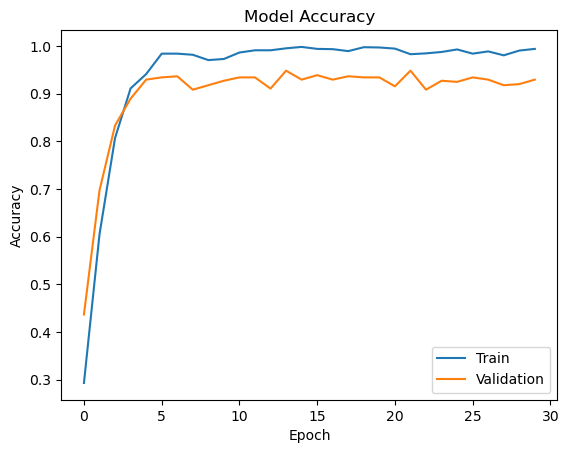

In [64]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


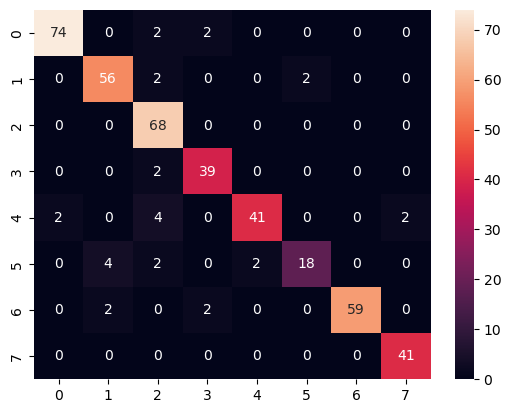

In [65]:
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True)
plt.show()

In [66]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", cnn_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9296 - loss: 0.3035
Test Loss: 0.3035012483596802
Test Accuracy: 0.9295774698257446


In [67]:
results = {
    "Model": ["CNN Spectrogram"],
    "Accuracy": [cnn_accuracy]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,CNN Spectrogram,0.929577


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_mfcc, y_train_mfcc)

rf_pred = rf_model.predict(X_test_mfcc)

rf_accuracy = accuracy_score(y_test_mfcc, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9270833333333334


In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_mfcc = scaler.fit_transform(X_train_mfcc)
X_test_mfcc = scaler.transform(X_test_mfcc)

In [70]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_mfcc, y_train_mfcc)

svm_pred = svm_model.predict(X_test_mfcc)

svm_accuracy = accuracy_score(y_test_mfcc, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7986111111111112


In [71]:
def extract_mfcc_cnn(dataset_path):

    signal, sr = librosa.load(dataset_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)

    return mfcc

X_mfcc_cnn = []
y_mfcc_cnn = []

for path, emotion in zip(df.path, df.emotion):

    mfcc = extract_mfcc_cnn(path)

    if mfcc.shape == (40,130):
        X_mfcc_cnn.append(mfcc)
        y_mfcc_cnn.append(emotion)

X_mfcc_cnn = np.array(X_mfcc_cnn)
X_mfcc_cnn = X_mfcc_cnn[..., np.newaxis]

y_mfcc_cnn = encoder.fit_transform(y_mfcc_cnn)

X_train_mfcc_cnn, X_test_mfcc_cnn, y_train_mfcc_cnn, y_test_mfcc_cnn = train_test_split(
    X_mfcc_cnn,
    y_mfcc_cnn,
    test_size=0.2,
    random_state=42
)

In [72]:
results = {
    "Model": [
        "CNN (Mel Spectrogram)",
        "Random Forest (MFCC)",
        "SVM (MFCC)"
    ],
    "Accuracy": [
        cnn_accuracy,
        rf_accuracy,
        svm_accuracy
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,CNN (Mel Spectrogram),0.929577
1,Random Forest (MFCC),0.927083
2,SVM (MFCC),0.798611


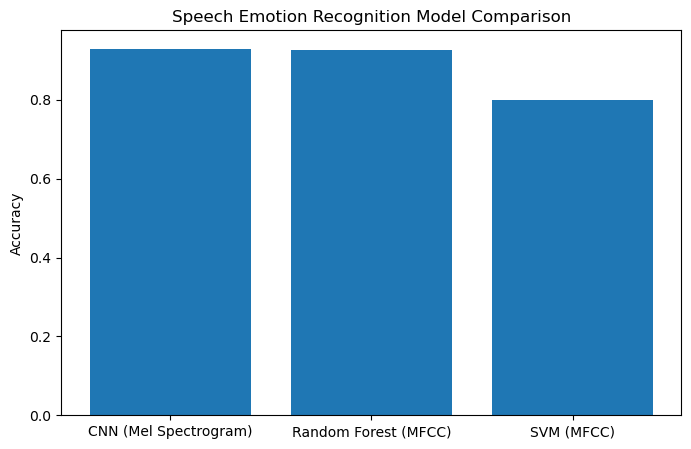

In [73]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.ylabel("Accuracy")
plt.title("Speech Emotion Recognition Model Comparison")

plt.show()

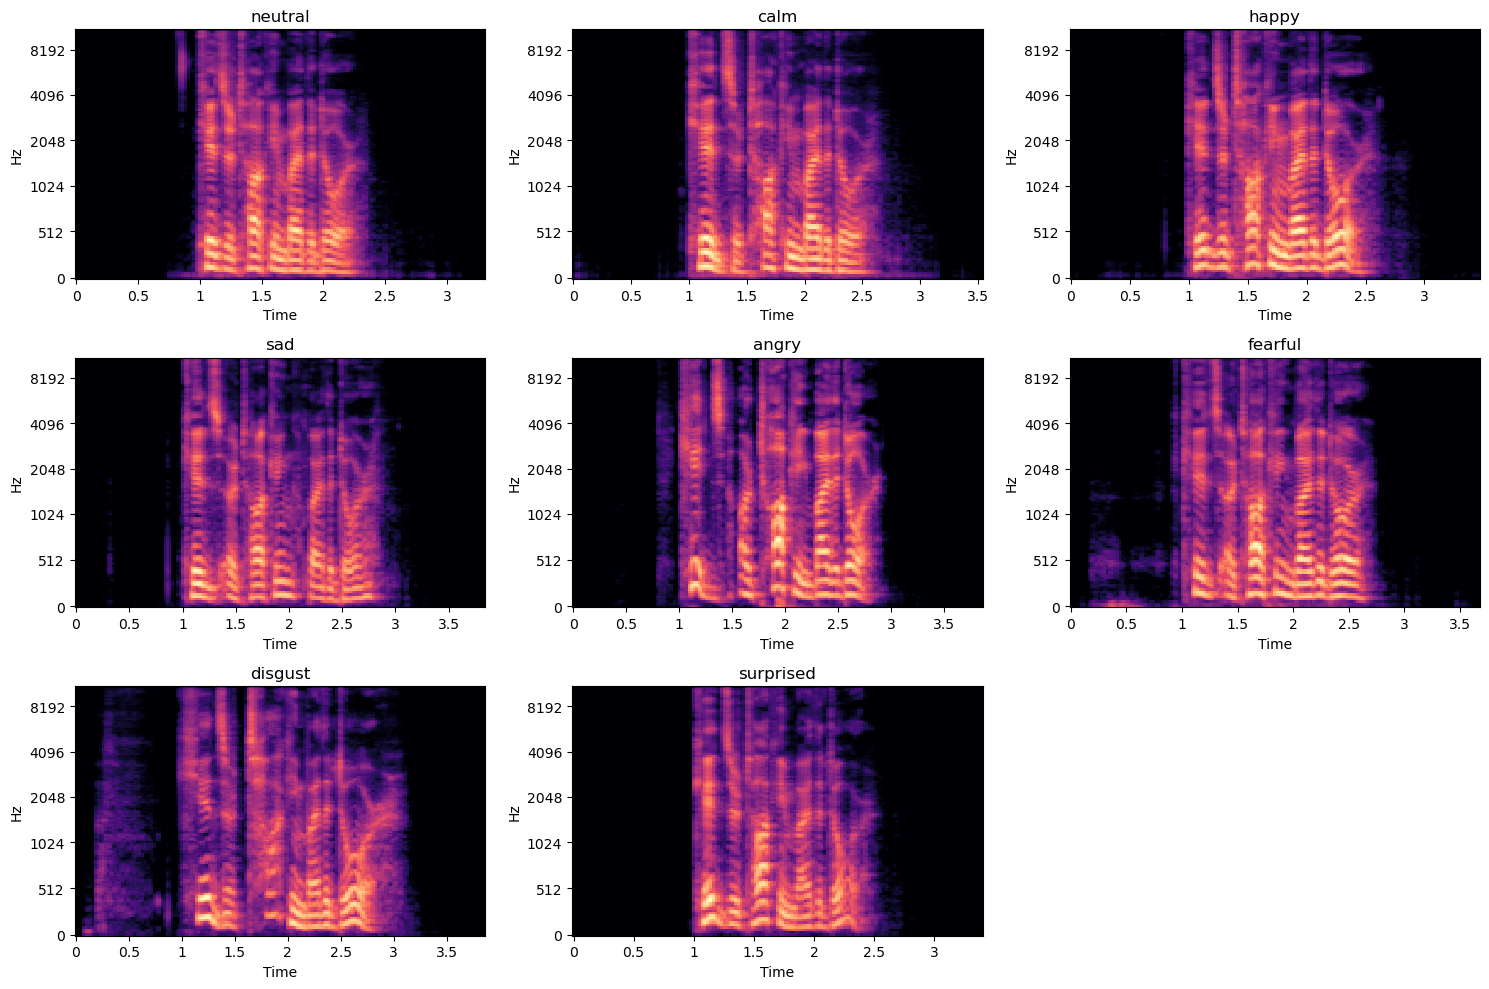

In [74]:
emotions = df["emotion"].unique()

plt.figure(figsize=(15,10))

for i, emotion in enumerate(emotions):

    sample_path = df[df["emotion"] == emotion].iloc[0]["path"]

    signal, sr = librosa.load(sample_path)

    spectrogram = librosa.feature.melspectrogram(
        y=signal,
        sr=sr
    )

    spectrogram_db = librosa.power_to_db(spectrogram)

    plt.subplot(3,3,i+1)

    librosa.display.specshow(
        spectrogram_db,
        x_axis='time',
        y_axis='mel'
    )

    plt.title(emotion)

plt.tight_layout()
plt.show()

In [76]:
import numpy as np

emotion_groups = df.groupby("emotion")

avg_spectrograms = {}

TARGET_TIME = 200   # fixed spectrogram width

for emotion, group in emotion_groups:

    specs = []

    for path in group.path[:20]:

        signal, sr = librosa.load(path)

        spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr
        )

        # ensure same width
        if spec.shape[1] < TARGET_TIME:
            pad_width = TARGET_TIME - spec.shape[1]
            spec = np.pad(spec, ((0,0),(0,pad_width)), mode='constant')

        else:
            spec = spec[:, :TARGET_TIME]

        specs.append(spec)

    specs = np.array(specs)

    avg_spec = np.mean(specs, axis=0)

    avg_spectrograms[emotion] = avg_spec

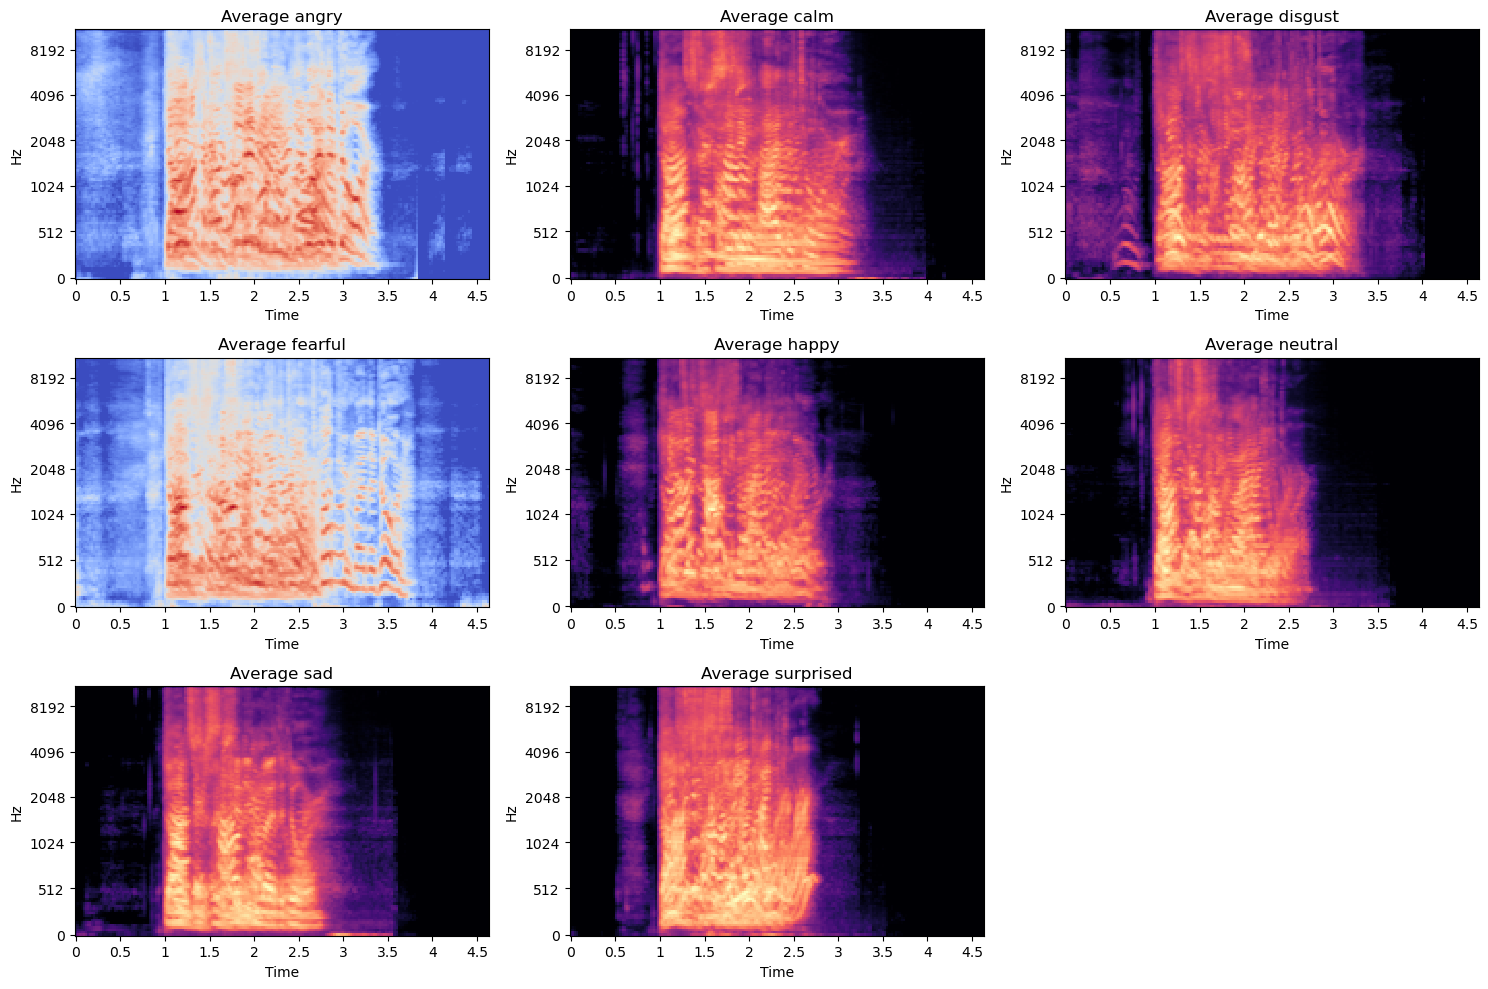

In [77]:
plt.figure(figsize=(15,10))

for i,(emotion,spec) in enumerate(avg_spectrograms.items()):

    plt.subplot(3,3,i+1)

    librosa.display.specshow(
        librosa.power_to_db(spec),
        x_axis='time',
        y_axis='mel'
    )

    plt.title("Average " + emotion)

plt.tight_layout()
plt.show()

In [78]:
emotion_energy = {}

for emotion,spec in avg_spectrograms.items():

    energy = np.mean(spec, axis=1)

    emotion_energy[emotion] = energy

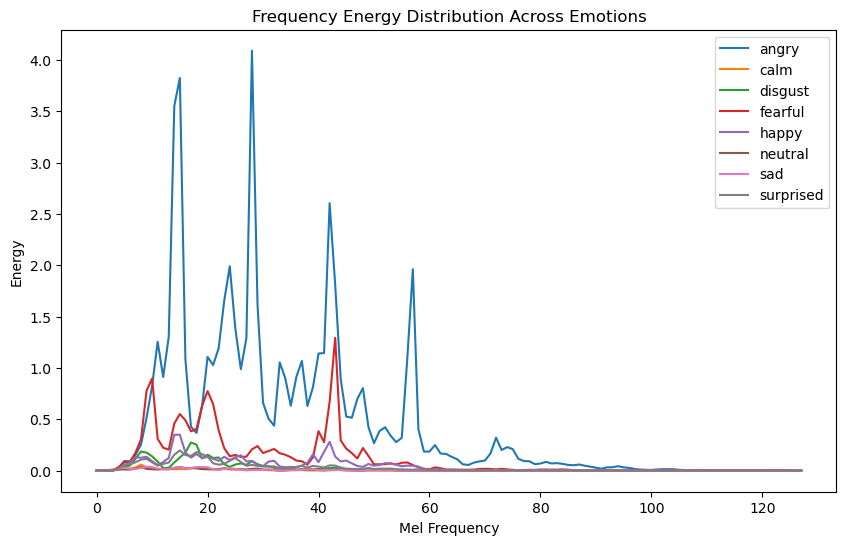

In [79]:
plt.figure(figsize=(10,6))

for emotion,energy in emotion_energy.items():

    plt.plot(energy, label=emotion)

plt.title("Frequency Energy Distribution Across Emotions")

plt.xlabel("Mel Frequency")

plt.ylabel("Energy")

plt.legend()

plt.show()